# Agentic Quantum–ML Laboratory for FX Target-Zone Risk

### A governed research loop for selecting quantum-inspired tunneling models and machine-learning tools

**Author:** Alejandro Reynoso  
**Research notebook:** Integrated Autonomous Intelligence  
**Environment:** Google Colab / Python 3  

> **Central question.** When an exchange rate is constrained by a lower and upper target-zone barrier, which combination of quantum-inspired escape models and machine-learning tools produces the most useful *out-of-sample* estimate of barrier-breach risk?

This notebook does not simply fit one model. It implements an **agentic research loop** that:

1. observes the target-zone process;
2. proposes model families;
3. passes each proposal through a governance gate;
4. executes walk-forward backtests;
5. critiques predictive and calibration failures;
6. updates its research memory;
7. builds hybrid and ensemble candidates; and
8. stops under explicit completion and budget rules.

The output is a reproducible model-selection decision, a locked-holdout evaluation, a current FX risk card, stress scenarios, and a complete audit trail.

## 1. The conceptual ladder

The notebook combines four layers that should not be confused:

| Layer | Role in the laboratory |
|---|---|
| **Target-zone economics** | Defines the bounded exchange-rate process, policy credibility, interventions, and the possibility of realignment or barrier failure. |
| **Quantum-inspired models** | Translate distance, effective energy, barrier height, and barrier width into nonlinear escape features. They are analogies and feature generators—not claims that currencies are quantum particles. |
| **Machine learning** | Learns empirical interactions among volatility, momentum, location inside the band, intervention proxies, and quantum-inspired features. |
| **Agentic loop** | Decides which candidates to test next, enforces the holdout lock and budgets, records evidence, and terminates transparently. |

### The model-selection principle

The notebook is permitted to conclude that the best model is:

- purely classical;
- purely quantum-inspired;
- a quantum–ML hybrid; or
- an ensemble.

The quantum analogy must **earn its place out of sample**.

## 2. Scientific status and limitations

“Tunneling” is used here as a disciplined mathematical analogy for a rare escape from a defended range. In physics, transmission probabilities follow from a specified Hamiltonian and wave equation. In this notebook, market observables are mapped to dimensionless analogues:

$
\text{distance to barrier}\rightarrow a_t,\qquad
\text{volatility/momentum/pressure}\rightarrow E_t,\qquad
\text{policy credibility}\rightarrow V_t.
$

A WKB-style transmission feature is then

$
T_t^{\mathrm{WKB}}
=
\exp\left[-2\gamma a_t
\sqrt{\frac{(V_t-E_t)_+}{h_{\mathrm{eff}}}}\right].
$

This can be useful as a **nonlinear rare-event feature**, but it is not a structural law of FX markets. Real target zones also involve endogenous central-bank behavior, reserve limits, jumps, credibility shifts, and policy realignments. The final model therefore remains an empirical risk model requiring economic validation, monitoring, and human oversight.

This notebook is educational research code, not investment advice or a production trading system.

In [1]:
#@title 3. Install the small set of Colab dependencies
import sys, subprocess, importlib.util

required = {
    "yfinance": "yfinance>=0.2.40",
}
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
if missing:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q"] +
        [required[pkg] for pkg in missing]
    )
print("Dependencies ready.")

Dependencies ready.


In [2]:
#@title 4. Imports, visual design, and reproducibility
from dataclasses import dataclass, asdict, field
from datetime import datetime, timezone
from copy import deepcopy
import hashlib
import json
import math
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import expit
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    GradientBoostingRegressor,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
SEED = 367
np.random.seed(SEED)

CAMBRIDGE_BLUE = "#003B5C"
CAMBRIDGE_LIGHT = "#6EC4E8"
CAMBRIDGE_RED = "#A71930"
CAMBRIDGE_GOLD = "#D6A84B"
INK = "#17212B"
PALE = "#EEF4F7"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5.5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.size": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print({
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
})

{'python': '3.12.13', 'numpy': '2.0.2', 'pandas': '2.2.2'}


In [3]:
#@title 5. Research configuration — edit this cell first
@dataclass
class ResearchConfig:
    # Data mode: "synthetic", "yfinance", or "csv"
    data_mode: str = "synthetic"
    ticker: str = "MXN=X"          # yfinance quotation: MXN per USD
    start: str = "2012-01-01"
    end: str | None = None
    csv_path: str = "/content/fx_target_zone.csv"

    # Synthetic laboratory band
    n_observations: int = 2800
    synthetic_center: float = 18.00
    synthetic_half_width: float = 0.80

    # For yfinance data, provide economically meaningful barriers.
    # Set both to numbers, or use rolling bands only as a statistical laboratory.
    static_lower_barrier: float | None = None
    static_upper_barrier: float | None = None
    allow_statistical_rolling_band: bool = True
    rolling_band_window: int = 252
    rolling_band_width_sigma: float = 2.0

    # Forecast and validation
    breach_horizon_days: int = 10
    holdout_fraction: float = 0.20
    n_walk_forward_splits: int = 5
    gap_days: int = 10
    max_agent_cycles: int = 5
    max_candidates: int = 80
    minimum_events: int = 25

    # Risk conversion
    fx_notional: float = 10_000_000.0
    exposure_sign: int = 1  # +1 loses when quoted FX falls; change to match exposure
    tail_alpha: float = 0.01

CFG = ResearchConfig()
CFG.gap_days = CFG.breach_horizon_days

print(json.dumps(asdict(CFG), indent=2))

{
  "data_mode": "synthetic",
  "ticker": "MXN=X",
  "start": "2012-01-01",
  "end": null,
  "csv_path": "/content/fx_target_zone.csv",
  "n_observations": 2800,
  "synthetic_center": 18.0,
  "synthetic_half_width": 0.8,
  "static_lower_barrier": null,
  "static_upper_barrier": null,
  "allow_statistical_rolling_band": true,
  "rolling_band_window": 252,
  "rolling_band_width_sigma": 2.0,
  "breach_horizon_days": 10,
  "holdout_fraction": 0.2,
  "n_walk_forward_splits": 5,
  "gap_days": 10,
  "max_agent_cycles": 5,
  "max_candidates": 80,
  "minimum_events": 25,
  "fx_notional": 10000000.0,
  "exposure_sign": 1,
  "tail_alpha": 0.01
}


### Data contract

The preferred production input is a CSV with:

```text
Date, FX, LowerBarrier, UpperBarrier
```

The barriers may vary through time. This is essential when a target zone is realigned.

The `yfinance` mode supplies a spot series but **does not supply an official policy band**. A rolling statistical band may be used for demonstration, but it must not be represented as an official target zone. The synthetic mode is the default because it lets the complete laboratory run without credentials and contains observable rare barrier escapes.

In [4]:
#@title 6. Data tools: synthetic target zone, CSV, or public spot series
def make_synthetic_target_zone(cfg: ResearchConfig) -> pd.DataFrame:
    rng = np.random.default_rng(SEED)
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=cfg.n_observations)
    n = len(dates)

    # A slowly moving central parity and a mildly varying band.
    center = cfg.synthetic_center * (
        1 + 0.012 * np.sin(np.linspace(0, 7 * np.pi, n))
    )
    half_width = cfg.synthetic_half_width * (
        1 + 0.10 * np.sin(np.linspace(0, 4 * np.pi, n) + 0.7)
    )

    x = np.zeros(n)              # normalized location around central parity
    pressure = np.zeros(n)       # latent speculative pressure
    vol_state = np.zeros(n)      # persistent volatility state
    tunnel_flag = np.zeros(n, dtype=int)

    for t in range(1, n):
        pressure[t] = 0.94 * pressure[t-1] + 0.30 * rng.normal()
        vol_state[t] = 0.97 * vol_state[t-1] + 0.10 * rng.normal()

        prev = x[t-1]
        near = np.clip((abs(prev) - 0.48) / 0.52, 0, 1)
        sigma = 0.035 * np.exp(0.30 * vol_state[t])
        # Intervention-like mean reversion strengthens near a credible edge.
        defense = 0.045 + 0.18 * near**2
        dx = (
            -defense * prev
            + 0.018 * pressure[t]
            + sigma * rng.standard_t(df=6)
        )

        # After an escape, policy action or market normalization pulls the rate back.
        if abs(prev) > 1:
            dx += -0.55 * (prev - np.sign(prev) * 0.68)

        # Rare nonlinear escape probability: location, pressure, and volatility interact.
        escape_prob = expit(
            -6.4
            + 5.0 * near
            + 1.15 * abs(pressure[t])
            + 0.75 * max(vol_state[t], 0)
        )
        if rng.random() < escape_prob:
            direction = np.sign(0.75 * pressure[t] + 0.25 * prev + rng.normal(scale=0.35))
            direction = 1 if direction == 0 else direction
            x[t] = direction * (1.03 + abs(rng.normal(0, 0.12)))
            tunnel_flag[t] = 1
        else:
            x[t] = np.clip(prev + dx, -1.35, 1.35)

    fx = center + half_width * x
    df = pd.DataFrame({
        "FX": fx,
        "LowerBarrier": center - half_width,
        "UpperBarrier": center + half_width,
        "SyntheticEscape": tunnel_flag,
    }, index=dates)
    df.index.name = "Date"
    return df


def load_csv_target_zone(cfg: ResearchConfig) -> pd.DataFrame:
    raw = pd.read_csv(cfg.csv_path)
    required = {"Date", "FX", "LowerBarrier", "UpperBarrier"}
    missing = required.difference(raw.columns)
    if missing:
        raise ValueError(f"CSV is missing required columns: {sorted(missing)}")
    raw["Date"] = pd.to_datetime(raw["Date"], utc=True).dt.tz_localize(None)
    out = raw.set_index("Date").sort_index()
    return out[["FX", "LowerBarrier", "UpperBarrier"]].astype(float)


def load_yfinance_target_zone(cfg: ResearchConfig) -> pd.DataFrame:
    import yfinance as yf
    raw = yf.download(
        cfg.ticker, start=cfg.start, end=cfg.end,
        auto_adjust=True, progress=False
    )
    if raw.empty:
        raise RuntimeError("No data returned by yfinance.")
    close = raw["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    out = pd.DataFrame({"FX": close.astype(float)}).dropna()

    if cfg.static_lower_barrier is not None and cfg.static_upper_barrier is not None:
        out["LowerBarrier"] = float(cfg.static_lower_barrier)
        out["UpperBarrier"] = float(cfg.static_upper_barrier)
    elif cfg.allow_statistical_rolling_band:
        # Demonstration only: this is not an official policy band.
        log_fx = np.log(out["FX"])
        center = log_fx.rolling(cfg.rolling_band_window, min_periods=100).mean()
        sigma = log_fx.rolling(cfg.rolling_band_window, min_periods=100).std()
        out["LowerBarrier"] = np.exp(
            center - cfg.rolling_band_width_sigma * sigma
        )
        out["UpperBarrier"] = np.exp(
            center + cfg.rolling_band_width_sigma * sigma
        )
        print("WARNING: using a statistical rolling band, not an official target zone.")
    else:
        raise ValueError("Supply static barriers or enable a statistical rolling band.")
    return out.dropna()


def load_data(cfg: ResearchConfig) -> pd.DataFrame:
    if cfg.data_mode == "synthetic":
        return make_synthetic_target_zone(cfg)
    if cfg.data_mode == "csv":
        return load_csv_target_zone(cfg)
    if cfg.data_mode == "yfinance":
        return load_yfinance_target_zone(cfg)
    raise ValueError("data_mode must be synthetic, csv, or yfinance")


raw = load_data(CFG)
assert (raw["UpperBarrier"] > raw["LowerBarrier"]).all()
assert raw[["FX", "LowerBarrier", "UpperBarrier"]].notna().all().all()
print(f"{len(raw):,} observations from {raw.index.min().date()} to {raw.index.max().date()}")
raw.tail()

2,800 observations from 2015-11-02 to 2026-07-24


,FX,LowerBarrier,UpperBarrier,SyntheticEscape
Date,,,,
2026-07-20,18.224717,17.156357,18.857217,0
2026-07-21,18.198417,17.154382,18.855799,0
2026-07-22,18.232190,17.152408,18.854380,0
2026-07-23,18.247713,17.150435,18.852959,0
2026-07-24,18.254442,17.148463,18.851537,0


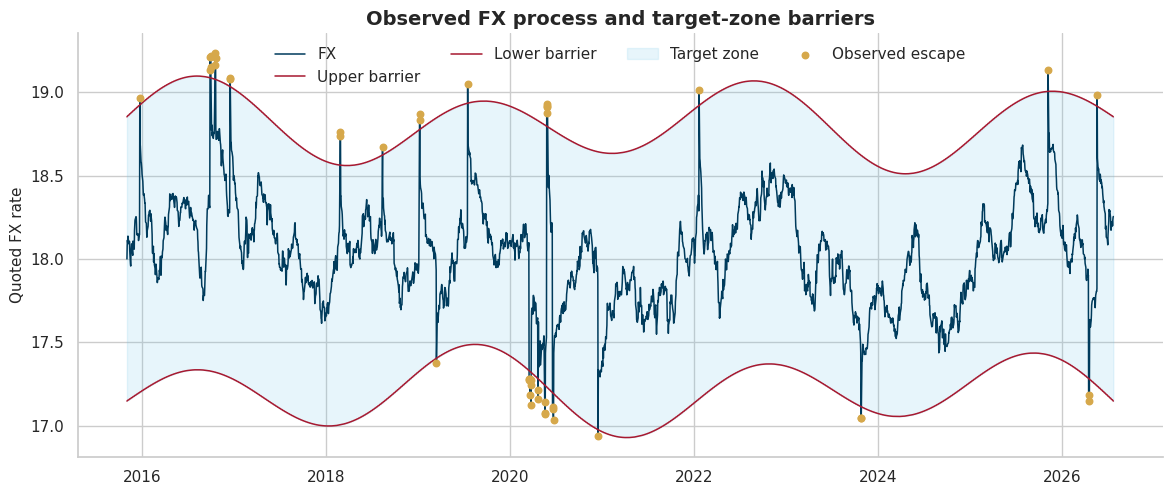

{'observed_escape_days': 44, 'escape_day_rate': 0.0157, 'median_band_width': 1.6001}


In [5]:
#@title 7. Observe the target zone
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(raw.index, raw["FX"], color=CAMBRIDGE_BLUE, lw=1.1, label="FX")
ax.plot(raw.index, raw["UpperBarrier"], color=CAMBRIDGE_RED, lw=1.1, label="Upper barrier")
ax.plot(raw.index, raw["LowerBarrier"], color=CAMBRIDGE_RED, lw=1.1, label="Lower barrier")
ax.fill_between(
    raw.index,
    raw["LowerBarrier"].to_numpy(),
    raw["UpperBarrier"].to_numpy(),
    color=CAMBRIDGE_LIGHT, alpha=0.16, label="Target zone"
)
outside = (raw["FX"] > raw["UpperBarrier"]) | (raw["FX"] < raw["LowerBarrier"])
ax.scatter(
    raw.index[outside], raw.loc[outside, "FX"],
    color=CAMBRIDGE_GOLD, s=22, zorder=5, label="Observed escape"
)
ax.set_title("Observed FX process and target-zone barriers")
ax.set_ylabel("Quoted FX rate")
ax.legend(ncol=4, frameon=False)
plt.show()

print({
    "observed_escape_days": int(outside.sum()),
    "escape_day_rate": round(float(outside.mean()), 4),
    "median_band_width": round(float((raw.UpperBarrier - raw.LowerBarrier).median()), 4),
})

## 8. Context assembly: barrier-aware features and targets

The risk question is path-dependent. For horizon \(H\), the event label is one if the FX rate crosses either contemporaneous barrier on **any** of the next \(H\) business days:

$
y_t^{(H)}
=
\mathbf{1}\left\{
\exists\,j\in\{1,\ldots,H\}:
S_{t+j}<L_{t+j}\ \lor\ S_{t+j}>U_{t+j}
\right\}.
$

The feature set uses only information available at time \(t\). A walk-forward validation gap equal to \(H\) reduces overlap between training labels and validation observations.

In [6]:
#@title 9. Build classical target-zone features and forward risk labels
def forward_matrix(series: pd.Series, horizon: int) -> pd.DataFrame:
    return pd.concat(
        {f"t+{j}": series.shift(-j) for j in range(1, horizon + 1)},
        axis=1,
    )


def engineer_classical_features(df: pd.DataFrame, horizon: int):
    x = df.copy().sort_index()
    fx = x["FX"].astype(float)
    lower = x["LowerBarrier"].astype(float)
    upper = x["UpperBarrier"].astype(float)
    width = (upper - lower).clip(lower=1e-9)
    mid = 0.5 * (upper + lower)

    ret = np.log(fx).diff()
    feat = pd.DataFrame(index=x.index)
    feat["ret_1"] = ret
    feat["ret_2"] = np.log(fx / fx.shift(2))
    feat["mom_5"] = np.log(fx / fx.shift(5))
    feat["mom_20"] = np.log(fx / fx.shift(20))
    feat["vol_5"] = ret.rolling(5).std() * np.sqrt(252)
    feat["vol_20"] = ret.rolling(20).std() * np.sqrt(252)
    feat["vol_60"] = ret.rolling(60).std() * np.sqrt(252)
    feat["skew_20"] = ret.rolling(20).skew()
    feat["kurt_60"] = ret.rolling(60).kurt()

    feat["location"] = ((fx - mid) / (0.5 * width)).clip(-1.75, 1.75)
    feat["dist_upper"] = ((upper - fx) / width).clip(-0.50, 1.50)
    feat["dist_lower"] = ((fx - lower) / width).clip(-0.50, 1.50)
    feat["dist_nearest"] = np.minimum(feat["dist_upper"], feat["dist_lower"]).clip(-0.50, 0.75)
    feat["band_width_pct"] = width / mid.abs().clip(lower=1e-9)
    feat["center_change_5"] = np.log(mid / mid.shift(5))

    daily_sigma = (feat["vol_20"] / np.sqrt(252)).clip(lower=1e-6)
    feat["momentum_energy"] = (feat["mom_5"].abs() / (daily_sigma * np.sqrt(5))).clip(0, 8)
    feat["vol_ratio"] = (feat["vol_5"] / feat["vol_60"].clip(lower=1e-6)).clip(0, 5)
    feat["barrier_pressure"] = (
        feat["momentum_energy"] / (feat["dist_nearest"].clip(lower=0) + 0.04)
    ).clip(0, 100)

    # Positive when the latest movement is back toward the center: a reduced-form
    # intervention/defense proxy, not an observed policy action.
    reversal = -np.sign(feat["location"].shift(1)) * ret
    feat["defense_proxy"] = (
        reversal.rolling(20).mean() /
        (ret.rolling(20).std().clip(lower=1e-6))
    ).clip(-3, 3)
    feat["near_edge"] = (feat["dist_nearest"] < 0.15).astype(float)

    fx_fwd = forward_matrix(fx, horizon)
    upper_fwd = forward_matrix(upper, horizon)
    lower_fwd = forward_matrix(lower, horizon)
    up_cross = fx_fwd.gt(upper_fwd)
    down_cross = fx_fwd.lt(lower_fwd)

    targets = pd.DataFrame(index=x.index)
    targets["y_breach"] = (up_cross.any(axis=1) | down_cross.any(axis=1)).astype(int)
    targets["y_up"] = up_cross.any(axis=1).astype(int)
    targets["y_down"] = down_cross.any(axis=1).astype(int)
    targets["fwd_return"] = np.log(fx.shift(-horizon) / fx)
    path_returns = fx_fwd.apply(np.log).sub(np.log(fx), axis=0)
    targets["fwd_min_return"] = path_returns.min(axis=1)
    targets["fwd_max_return"] = path_returns.max(axis=1)

    combined = feat.join(targets).replace([np.inf, -np.inf], np.nan).dropna()
    classical_cols = feat.columns.tolist()
    return combined, classical_cols


dataset, CLASSICAL_COLS = engineer_classical_features(raw, CFG.breach_horizon_days)
event_rate = dataset["y_breach"].mean()
event_count = int(dataset["y_breach"].sum())

print({
    "usable_observations": len(dataset),
    "features": len(CLASSICAL_COLS),
    "horizon_days": CFG.breach_horizon_days,
    "breach_events": event_count,
    "breach_label_rate": round(float(event_rate), 4),
})
if event_count < CFG.minimum_events:
    raise ValueError(
        "Too few barrier events for this experiment. Lengthen the sample, "
        "increase the horizon, or use economically justified barriers."
    )
dataset.tail()

{'usable_observations': 2730, 'features': 20, 'horizon_days': 10, 'breach_events': 208, 'breach_label_rate': 0.0762}


,ret_1,ret_2,mom_5,mom_20,vol_5,vol_20,vol_60,skew_20,kurt_60,location,...,vol_ratio,barrier_pressure,defense_proxy,near_edge,y_breach,y_up,y_down,fwd_return,fwd_min_return,fwd_max_return
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-06,0.004555,0.007859,0.005712,-0.012420,0.041478,0.033825,0.173663,0.484925,22.590982,0.240153,...,0.238842,2.854909,0.291447,0.0,0,0,0,-0.000140,-0.003022,0.003748
2026-07-07,0.003748,0.008303,0.009590,-0.007091,0.043090,0.036963,0.173753,0.378925,22.517440,0.322792,...,0.247994,4.865077,0.152278,0.0,0,0,0,-0.005332,-0.006770,-0.000267
2026-07-08,-0.000267,0.003482,0.010578,-0.007820,0.038875,0.036840,0.173654,0.432499,22.542032,0.318923,...,0.223865,5.356489,0.168476,0.0,0,0,0,-0.003211,-0.006504,-0.000040
2026-07-09,-0.000458,-0.000725,0.010882,-0.007403,0.037489,0.036797,0.173662,0.404582,22.552054,0.310936,...,0.215873,5.459959,0.159685,0.0,0,0,0,-0.001902,-0.006046,0.000418
2026-07-10,0.000418,-0.000040,0.007996,-0.005420,0.037620,0.036616,0.148135,0.277712,34.772999,0.321823,...,0.253960,4.089754,0.117489,0.0,0,0,0,-0.001951,-0.006463,-0.001951


## 10. Quantum-inspired feature factory

Three related nonlinear representations are built for each candidate parameterization:

1. **WKB escape:** exponential decay through the effective forbidden region.
2. **Rectangular-barrier transmission:** a finite-barrier analogue with a hyperbolic-sine penalty.
3. **Resonant two-barrier escape:** a deliberately flexible two-sided feature allowing location-dependent amplification.

The mapping is dimensionless and explicit. The agent searches a small governed grid of effective barrier scale, action scale, and effective \(\hbar\). This is model selection—not a measurement of physical constants.

In [7]:
#@title 11. Quantum-inspired tunneling feature factory
@dataclass(frozen=True)
class QuantumConfig:
    barrier_scale: float = 1.0
    action_scale: float = 4.0
    h_eff: float = 0.50
    resonance_frequency: float = 2.0

    @property
    def label(self):
        return (
            f"V{self.barrier_scale:g}_G{self.action_scale:g}_"
            f"H{self.h_eff:g}_R{self.resonance_frequency:g}"
        )


def quantum_features(classical: pd.DataFrame, qcfg: QuantumConfig) -> pd.DataFrame:
    f = classical
    eps = 1e-9

    vol_component = np.tanh(f["vol_ratio"].clip(lower=0) / 2.0)
    mom_component = np.tanh(f["momentum_energy"].clip(lower=0) / 2.5)
    pressure_component = np.tanh(f["barrier_pressure"].clip(lower=0) / 12.0)
    energy = (
        0.38 * vol_component +
        0.37 * mom_component +
        0.25 * pressure_component
    ).clip(0, 1.5)

    credibility = expit(0.8 * f["defense_proxy"])
    barrier = qcfg.barrier_scale * (0.70 + 0.55 * credibility)

    def one_wall(distance):
        a = np.clip(distance, 0, 1.25)
        delta = np.maximum(barrier - energy, 0)
        wkb = np.exp(
            -2.0 * qcfg.action_scale * a *
            np.sqrt(delta / max(qcfg.h_eff, eps))
        )
        # When effective energy exceeds the barrier, use a smooth over-barrier limit.
        over = expit(5.0 * (energy - barrier))
        wkb = np.where(energy >= barrier, over, wkb)

        safe_e = np.maximum(energy, 1e-5)
        safe_delta = np.maximum(barrier - energy, 1e-5)
        z = qcfg.action_scale * a * np.sqrt(safe_delta / max(qcfg.h_eff, eps))
        z = np.clip(z, 0, 20)
        penalty = (
            barrier**2 * np.sinh(z)**2 /
            (4.0 * safe_e * safe_delta + eps)
        )
        rectangular = 1.0 / (1.0 + penalty)
        rectangular = np.where(energy >= barrier, over, rectangular)
        return np.clip(wkb, 1e-7, 1 - 1e-7), np.clip(rectangular, 1e-7, 1 - 1e-7)

    up_wkb, up_rect = one_wall(f["dist_upper"])
    down_wkb, down_rect = one_wall(f["dist_lower"])

    two_sided_wkb = 1 - (1 - up_wkb) * (1 - down_wkb)
    two_sided_rect = 1 - (1 - up_rect) * (1 - down_rect)
    resonance = (
        two_sided_rect *
        (0.72 + 0.28 * np.cos(qcfg.resonance_frequency * np.pi * f["location"])**2)
    )

    q = pd.DataFrame(index=f.index)
    q["q_energy"] = energy
    q["q_barrier"] = barrier
    q["q_wkb_escape"] = np.clip(two_sided_wkb, 1e-7, 1 - 1e-7)
    q["q_rect_escape"] = np.clip(two_sided_rect, 1e-7, 1 - 1e-7)
    q["q_resonant_escape"] = np.clip(resonance, 1e-7, 1 - 1e-7)
    q["q_direction"] = np.clip(up_wkb - down_wkb, -1, 1)
    return q


Q_GRID = [
    QuantumConfig(v, g, h, r)
    for v in (0.75, 1.00, 1.25)
    for g in (2.5, 4.0)
    for h in (0.35, 0.65)
    for r in (1.0, 2.0)
]
Q_COLS = list(quantum_features(dataset[CLASSICAL_COLS], Q_GRID[0]).columns)
print(f"{len(Q_GRID)} governed quantum parameterizations; {len(Q_COLS)} quantum features.")

24 governed quantum parameterizations; 6 quantum features.


## 12. The executable agentic loop

The loop has separate responsibilities:

$
s_t=(g,x_t,m_t,\mathcal{T},\rho,b_t)
$

$
a_t=\pi(a\mid s_t),\quad
\widehat a_t=G(a_t,\rho,s_t),\quad
o_t=E(\widehat a_t),\quad
s_{t+1}=U(s_t,\widehat a_t,o_t).
$

In this notebook:

- the **reasoner** selects the next research phase;
- the **policy gate** locks the final holdout, limits candidate count, and blocks invalid experiments;
- the **tools** run time-aware backtests and blend searches;
- the **observation** is a metrics table and out-of-fold prediction vector;
- the **memory** is the leaderboard plus audit log;
- the **stop rule** ends at completion, budget exhaustion, or a safety failure.

The reasoner is deliberately deterministic so the scientific result is reproducible. An LLM could propose additional candidates, but it should not be allowed to bypass the same validation and governance gates.

In [8]:
#@title 13. Evaluation metrics and time-aware candidate models
def expected_calibration_error(y_true, p, n_bins=10):
    y_true = np.asarray(y_true)
    p = np.asarray(p)
    edges = np.linspace(0, 1, n_bins + 1)
    ids = np.clip(np.digitize(p, edges[1:-1]), 0, n_bins - 1)
    ece = 0.0
    for b in range(n_bins):
        mask = ids == b
        if mask.any():
            ece += mask.mean() * abs(y_true[mask].mean() - p[mask].mean())
    return float(ece)


def safe_roc_auc(y, p):
    return float(roc_auc_score(y, p)) if len(np.unique(y)) == 2 else 0.5


def safe_pr_auc(y, p):
    return float(average_precision_score(y, p)) if np.sum(y) > 0 else 0.0


def probability_metrics(y, p):
    y = np.asarray(y).astype(int)
    p = np.clip(np.asarray(p).astype(float), 1e-6, 1 - 1e-6)
    # Select exactly the top decile by stable rank. Thresholding alone would
    # classify every observation as "top decile" when probabilities are tied.
    n_top = max(1, int(np.ceil(0.10 * len(p))))
    cutoff = np.sort(p)[-n_top]
    strict = p > cutoff
    tied = p == cutoff
    slots_for_ties = max(n_top - int(strict.sum()), 0)
    tie_weight = slots_for_ties / max(int(tied.sum()), 1)
    expected_hits = float(y[strict].sum() + tie_weight * y[tied].sum())
    recall_top_decile = expected_hits / max(float(y.sum()), 1.0)
    result = {
        "brier": float(brier_score_loss(y, p)),
        "log_loss": float(log_loss(y, p, labels=[0, 1])),
        "roc_auc": safe_roc_auc(y, p),
        "pr_auc": safe_pr_auc(y, p),
        "ece": expected_calibration_error(y, p),
        "recall_top_decile": recall_top_decile,
    }
    # Lower is better. Calibration and rare-event ranking both matter.
    result["decision_loss"] = (
        0.40 * result["brier"]
        + 0.15 * result["log_loss"]
        + 0.15 * (1 - result["roc_auc"])
        + 0.15 * (1 - result["pr_auc"])
        + 0.10 * result["ece"]
        + 0.05 * (1 - result["recall_top_decile"])
    )
    return result


def make_estimator(family):
    if family == "logit":
        return Pipeline([
            ("scale", StandardScaler()),
            ("model", LogisticRegression(
                C=0.7, max_iter=3000, solver="lbfgs", random_state=SEED
            )),
        ])
    if family == "random_forest":
        return RandomForestClassifier(
            n_estimators=260,
            max_depth=7,
            min_samples_leaf=18,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1,
        )
    if family == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(
            max_iter=180,
            learning_rate=0.055,
            max_leaf_nodes=15,
            min_samples_leaf=22,
            l2_regularization=1.2,
            random_state=SEED,
        )
    raise ValueError(f"Unknown family: {family}")


def frame_for_qcfg(base: pd.DataFrame, qcfg: QuantumConfig | None):
    if qcfg is None:
        return base[CLASSICAL_COLS].copy()
    return base[CLASSICAL_COLS].join(quantum_features(base[CLASSICAL_COLS], qcfg))


def cols_for_feature_set(feature_set):
    if feature_set == "classical":
        return CLASSICAL_COLS
    if feature_set == "quantum_only":
        return Q_COLS
    if feature_set == "hybrid":
        return CLASSICAL_COLS + Q_COLS
    raise ValueError(feature_set)


def evaluate_candidate(base_design, spec, cfg):
    qcfg = spec.get("qcfg")
    frame = frame_for_qcfg(base_design, qcfg)
    cols = cols_for_feature_set(spec["feature_set"])
    X = frame[cols]
    y = base_design["y_breach"].astype(int)

    splitter = TimeSeriesSplit(
        n_splits=cfg.n_walk_forward_splits,
        gap=cfg.gap_days,
    )
    pred = pd.Series(np.nan, index=base_design.index, dtype=float)
    fold_rows = []

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X), start=1):
        y_train = y.iloc[train_idx]
        if y_train.nunique() < 2:
            raise RuntimeError("A training fold contains only one class.")
        model = make_estimator(spec["family"])
        model.fit(X.iloc[train_idx], y_train)
        p = model.predict_proba(X.iloc[test_idx])[:, 1]
        pred.iloc[test_idx] = p
        fold_metric = probability_metrics(y.iloc[test_idx], p)
        fold_metric["fold"] = fold
        fold_metric["n_train"] = len(train_idx)
        fold_metric["n_test"] = len(test_idx)
        fold_rows.append(fold_metric)

    valid = pred.notna()
    metrics = probability_metrics(y.loc[valid], pred.loc[valid])
    metrics.update({
        "name": spec["name"],
        "family": spec["family"],
        "feature_set": spec["feature_set"],
        "qcfg": qcfg.label if qcfg else None,
        "n_oof": int(valid.sum()),
    })
    return {
        "spec": deepcopy(spec),
        "metrics": metrics,
        "pred": pred,
        "fold_metrics": pd.DataFrame(fold_rows),
    }


def evaluate_historical_rate(base_design, cfg):
    y = base_design["y_breach"].astype(int)
    splitter = TimeSeriesSplit(n_splits=cfg.n_walk_forward_splits, gap=cfg.gap_days)
    pred = pd.Series(np.nan, index=base_design.index, dtype=float)
    for train_idx, test_idx in splitter.split(base_design):
        pred.iloc[test_idx] = float(y.iloc[train_idx].mean())
    valid = pred.notna()
    m = probability_metrics(y.loc[valid], pred.loc[valid])
    spec = {"name": "Historical event rate", "kind": "constant"}
    m.update({
        "name": spec["name"], "family": "constant",
        "feature_set": "none", "qcfg": None, "n_oof": int(valid.sum())
    })
    return {"spec": spec, "metrics": m, "pred": pred, "fold_metrics": pd.DataFrame()}

In [9]:
#@title 14. Split design data from the locked final holdout
split_at = int(len(dataset) * (1 - CFG.holdout_fraction))
DESIGN = dataset.iloc[:split_at].copy()
HOLDOUT = dataset.iloc[split_at:].copy()

assert DESIGN.index.max() < HOLDOUT.index.min()
assert DESIGN["y_breach"].sum() >= CFG.minimum_events
assert HOLDOUT["y_breach"].sum() > 0

DATA_FINGERPRINT = hashlib.sha256(
    pd.util.hash_pandas_object(dataset[["FX"] if "FX" in dataset.columns else CLASSICAL_COLS[:1]], index=True)
    .values.tobytes()
).hexdigest()[:16]

print({
    "design_period": [str(DESIGN.index.min().date()), str(DESIGN.index.max().date())],
    "design_n": len(DESIGN),
    "design_events": int(DESIGN.y_breach.sum()),
    "LOCKED_holdout_period": [str(HOLDOUT.index.min().date()), str(HOLDOUT.index.max().date())],
    "LOCKED_holdout_n": len(HOLDOUT),
    "LOCKED_holdout_events": int(HOLDOUT.y_breach.sum()),
    "data_fingerprint": DATA_FINGERPRINT,
})

{'design_period': ['2016-01-25', '2024-06-06'], 'design_n': 2184, 'design_events': 177, 'LOCKED_holdout_period': ['2024-06-07', '2026-07-10'], 'LOCKED_holdout_n': 546, 'LOCKED_holdout_events': 31, 'data_fingerprint': 'bc43b15b49998637'}


In [10]:
#@title 15. Agent state, governance gate, tools, and stop rule
@dataclass
class AgentState:
    goal: str
    phase: str = "baseline"
    cycle: int = 0
    candidates_used: int = 0
    holdout_locked: bool = True
    best_quantum_config: QuantumConfig | None = None
    results: list = field(default_factory=list)
    audit: list = field(default_factory=list)
    outcome: str | None = None


def audit(state, event, **details):
    state.audit.append({
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "cycle": state.cycle,
        "phase": state.phase,
        "event": event,
        **details,
    })


def reasoner(state: AgentState):
    # A reproducible policy that proposes the next research action.
    actions = {
        "baseline": {
            "tool": "evaluate_baselines",
            "rationale": "Establish the classical and no-skill benchmarks."
        },
        "quantum_search": {
            "tool": "search_quantum_models",
            "rationale": "Test whether tunneling features contain out-of-sample signal."
        },
        "hybrid_search": {
            "tool": "evaluate_hybrids",
            "rationale": "Let ML learn interactions between economic and tunneling features."
        },
        "blend_search": {
            "tool": "optimize_blends",
            "rationale": "Test whether diversified probability forecasts reduce decision loss."
        },
        "select": {
            "tool": "select_champion",
            "rationale": "Choose the lowest-loss candidate before unlocking the holdout."
        },
    }
    return actions.get(state.phase, {"tool": "stop", "rationale": "No valid next phase."})


def policy_gate(state: AgentState, proposal, cfg: ResearchConfig):
    if state.cycle >= cfg.max_agent_cycles:
        return False, "Cycle budget exhausted."
    if state.candidates_used >= cfg.max_candidates:
        return False, "Candidate budget exhausted."
    if not state.holdout_locked and state.phase != "complete":
        return False, "Holdout was unlocked before model selection completed."
    if proposal["tool"] not in {
        "evaluate_baselines", "search_quantum_models", "evaluate_hybrids",
        "optimize_blends", "select_champion", "stop"
    }:
        return False, "Tool not allow-listed."
    return True, "Authorized."


def add_result(state, result):
    state.results.append(result)
    state.candidates_used += 1


def tool_evaluate_baselines(state, design, cfg):
    add_result(state, evaluate_historical_rate(design, cfg))
    for family in ("logit", "random_forest", "hist_gradient_boosting"):
        spec = {
            "name": f"Classical · {family}",
            "kind": "model",
            "family": family,
            "feature_set": "classical",
            "qcfg": None,
        }
        add_result(state, evaluate_candidate(design, spec, cfg))
    state.phase = "quantum_search"
    return "Four baseline candidates evaluated."


def tool_search_quantum_models(state, design, cfg):
    q_results = []
    for qcfg in Q_GRID:
        spec = {
            "name": f"Quantum-only · logit · {qcfg.label}",
            "kind": "model",
            "family": "logit",
            "feature_set": "quantum_only",
            "qcfg": qcfg,
        }
        result = evaluate_candidate(design, spec, cfg)
        add_result(state, result)
        q_results.append(result)
    best = min(q_results, key=lambda r: r["metrics"]["decision_loss"])
    state.best_quantum_config = best["spec"]["qcfg"]
    state.phase = "hybrid_search"
    return f"Best quantum map: {state.best_quantum_config.label}"


def tool_evaluate_hybrids(state, design, cfg):
    qcfg = state.best_quantum_config
    for family in ("logit", "random_forest", "hist_gradient_boosting"):
        spec = {
            "name": f"Hybrid · {family} · {qcfg.label}",
            "kind": "model",
            "family": family,
            "feature_set": "hybrid",
            "qcfg": qcfg,
        }
        add_result(state, evaluate_candidate(design, spec, cfg))
    state.phase = "blend_search"
    return "Three quantum–ML hybrids evaluated."


def result_group(state, feature_set):
    return [
        r for r in state.results
        if r["metrics"]["feature_set"] == feature_set and r["spec"].get("kind") == "model"
    ]


def tool_optimize_blends(state, design, cfg):
    classical = min(result_group(state, "classical"), key=lambda r: r["metrics"]["decision_loss"])
    hybrid = min(result_group(state, "hybrid"), key=lambda r: r["metrics"]["decision_loss"])
    quantum = min(result_group(state, "quantum_only"), key=lambda r: r["metrics"]["decision_loss"])

    y = design["y_breach"]
    components = [
        ("Classical+Hybrid", classical, hybrid),
        ("Quantum+Hybrid", quantum, hybrid),
    ]
    for label, left, right in components:
        valid = left["pred"].notna() & right["pred"].notna()
        for alpha in np.linspace(0.15, 0.85, 8):
            # alpha weights the second component.
            p = (1 - alpha) * left["pred"].loc[valid] + alpha * right["pred"].loc[valid]
            m = probability_metrics(y.loc[valid], p)
            spec = {
                "name": f"Blend · {label} · α={alpha:.2f}",
                "kind": "blend",
                "alpha": float(alpha),
                "left": deepcopy(left["spec"]),
                "right": deepcopy(right["spec"]),
            }
            m.update({
                "name": spec["name"],
                "family": "probability_blend",
                "feature_set": label,
                "qcfg": state.best_quantum_config.label,
                "n_oof": int(valid.sum()),
            })
            add_result(state, {
                "spec": spec,
                "metrics": m,
                "pred": pd.Series(p, index=p.index),
                "fold_metrics": pd.DataFrame(),
            })
    state.phase = "select"
    return "Sixteen governed probability blends evaluated."


def tool_select_champion(state):
    champion = min(state.results, key=lambda r: r["metrics"]["decision_loss"])
    state.outcome = "complete"
    state.phase = "complete"
    state.holdout_locked = False
    return champion


def execute_proposal(state, proposal, design, cfg):
    tool = proposal["tool"]
    if tool == "evaluate_baselines":
        return tool_evaluate_baselines(state, design, cfg)
    if tool == "search_quantum_models":
        return tool_search_quantum_models(state, design, cfg)
    if tool == "evaluate_hybrids":
        return tool_evaluate_hybrids(state, design, cfg)
    if tool == "optimize_blends":
        return tool_optimize_blends(state, design, cfg)
    if tool == "select_champion":
        return tool_select_champion(state)
    state.outcome = "fail_safely"
    return "Stopped without a champion."


def run_agentic_research_loop(design, cfg):
    state = AgentState(
        goal=(
            "Select the most defensible combination of quantum-inspired "
            "tunneling features and ML tools for target-zone breach risk."
        )
    )
    audit(state, "run_started", goal=state.goal, data_fingerprint=DATA_FINGERPRINT)

    while state.outcome is None:
        proposal = reasoner(state)
        audit(state, "action_proposed", proposal=proposal)
        authorized, gate_message = policy_gate(state, proposal, cfg)
        audit(state, "policy_gate", authorized=authorized, message=gate_message)
        if not authorized:
            state.outcome = "fail_safely"
            audit(state, "run_closed", outcome=state.outcome)
            break

        observation = execute_proposal(state, proposal, design, cfg)
        if isinstance(observation, dict):
            obs_text = observation["metrics"]["name"]
        else:
            obs_text = str(observation)
        audit(state, "tool_observation", observation=obs_text)
        state.cycle += 1
        audit(
            state, "state_updated",
            candidates_used=state.candidates_used,
            next_phase=state.phase,
        )

        if state.outcome is not None:
            audit(state, "run_closed", outcome=state.outcome)
            break
    return state

In [11]:
#@title 16. Run the autonomous research loop
STATE = run_agentic_research_loop(DESIGN, CFG)
if STATE.outcome != "complete":
    raise RuntimeError(f"Research loop ended with: {STATE.outcome}")

LEADERBOARD = (
    pd.DataFrame([r["metrics"] for r in STATE.results])
    .sort_values("decision_loss")
    .reset_index(drop=True)
)
CHAMPION_RESULT = min(STATE.results, key=lambda r: r["metrics"]["decision_loss"])
CHAMPION_SPEC = CHAMPION_RESULT["spec"]

print(f"Outcome: {STATE.outcome}")
print(f"Cycles: {STATE.cycle}")
print(f"Candidates evaluated: {STATE.candidates_used}")
print(f"Selected champion: {CHAMPION_SPEC['name']}")

display_cols = [
    "name", "decision_loss", "brier", "log_loss", "roc_auc",
    "pr_auc", "ece", "recall_top_decile", "feature_set"
]
LEADERBOARD[display_cols].head(15).round({
    "decision_loss": 4, "brier": 4, "log_loss": 4,
    "roc_auc": 3, "pr_auc": 3, "ece": 3,
    "recall_top_decile": 3,
})

Outcome: complete
Cycles: 5
Candidates evaluated: 47
Selected champion: Blend · Quantum+Hybrid · α=0.15


,name,decision_loss,brier,log_loss,roc_auc,pr_auc,ece,recall_top_decile,feature_set
0,Blend · Quantum+Hybrid · α=0.15,0.3353,0.0747,0.2953,0.450,0.099,0.023,0.177,Quantum+Hybrid
1,Blend · Quantum+Hybrid · α=0.25,0.3382,0.0760,0.2991,0.456,0.097,0.042,0.163,Quantum+Hybrid
2,Quantum-only · logit · V0.75_G2.5_H0.65_R1,0.3400,0.0740,0.2958,0.425,0.096,0.021,0.156,quantum_only
3,Quantum-only · logit · V1.25_G4_H0.35_R1,0.3401,0.0724,0.2994,0.426,0.104,0.017,0.121,quantum_only
4,Quantum-only · logit · V1_G4_H0.35_R1,0.3403,0.0727,0.3042,0.436,0.098,0.016,0.121,quantum_only
5,Quantum-only · logit · V1_G4_H0.35_R2,0.3405,0.0729,0.3030,0.429,0.097,0.014,0.135,quantum_only
6,Quantum-only · logit · V0.75_G2.5_H0.65_R2,0.3408,0.0743,0.2987,0.423,0.096,0.025,0.170,quantum_only
7,Blend · Quantum+Hybrid · α=0.35,0.3414,0.0778,0.3050,0.466,0.095,0.058,0.142,Quantum+Hybrid
8,Quantum-only · logit · V1.25_G4_H0.35_R2,0.3416,0.0726,0.2975,0.420,0.098,0.017,0.121,quantum_only
9,Quantum-only · logit · V0.75_G4_H0.35_R2,0.3417,0.0729,0.2891,0.400,0.107,0.019,0.135,quantum_only


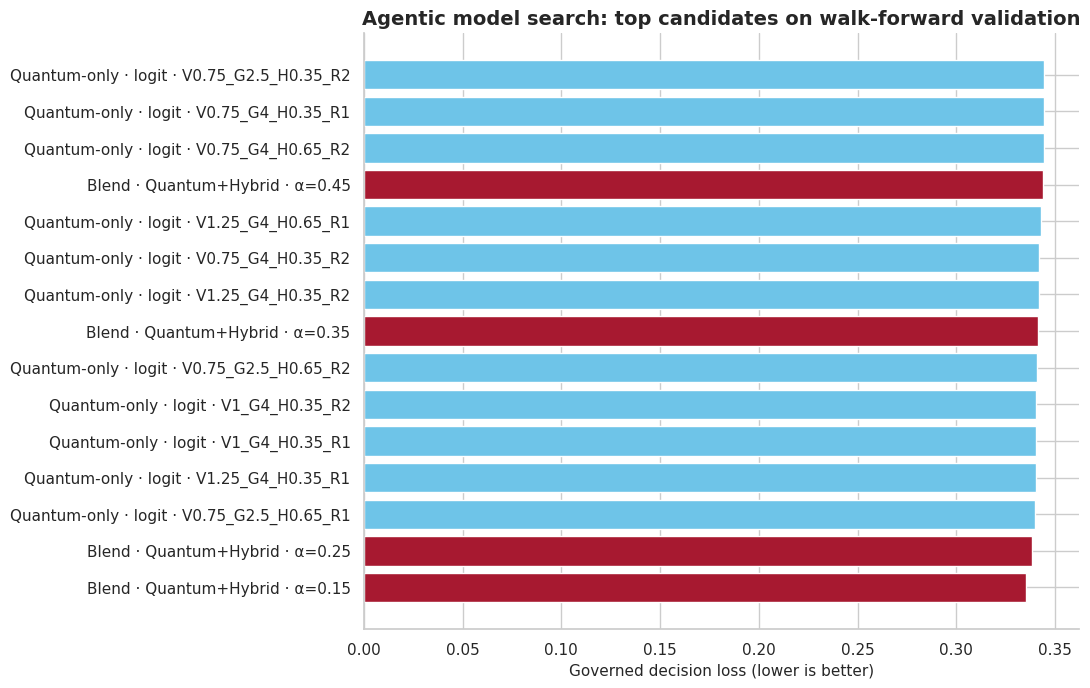

,candidate,decision_loss,improvement_vs_classical_pct
0,Best classical,0.366208,0.000000
1,Best quantum-only,0.340015,7.152681
2,Best hybrid,0.369053,-0.776694
3,Champion,0.335321,8.434429


In [12]:
#@title 17. Visualize what the loop learned
top = LEADERBOARD.head(15).sort_values("decision_loss", ascending=True)
fig, ax = plt.subplots(figsize=(11, 7))
colors = [
    CAMBRIDGE_RED if "Hybrid" in n or "Blend" in n
    else CAMBRIDGE_LIGHT if "Quantum" in n
    else CAMBRIDGE_BLUE
    for n in top["name"]
]
ax.barh(top["name"], top["decision_loss"], color=colors)
ax.set_xlabel("Governed decision loss (lower is better)")
ax.set_title("Agentic model search: top candidates on walk-forward validation")
plt.tight_layout()
plt.show()

best_classical = LEADERBOARD[LEADERBOARD.feature_set == "classical"].iloc[0]
best_quantum = LEADERBOARD[LEADERBOARD.feature_set == "quantum_only"].iloc[0]
hybrid_rows = LEADERBOARD[LEADERBOARD.feature_set == "hybrid"]
best_hybrid = hybrid_rows.iloc[0]

comparison = pd.DataFrame({
    "candidate": ["Best classical", "Best quantum-only", "Best hybrid", "Champion"],
    "decision_loss": [
        best_classical.decision_loss,
        best_quantum.decision_loss,
        best_hybrid.decision_loss,
        LEADERBOARD.iloc[0].decision_loss,
    ]
})
comparison["improvement_vs_classical_pct"] = (
    100 * (best_classical.decision_loss - comparison.decision_loss) /
    best_classical.decision_loss
)
comparison

## 18. Governance transition: unlock the holdout once

Only after the champion specification is fixed does the notebook unlock the final chronological holdout. No hyperparameter, feature set, blend weight, or model family may be changed in response to the holdout result.

This is a one-shot estimate of model-selection performance. If the result is disappointing, the proper response is to document it and begin a **new experiment with a new untouched holdout**, not to keep tuning on the same period.

In [13]:
#@title 19. Fit any champion specification and score the locked holdout
def fit_spec(spec, train):
    kind = spec["kind"]
    if kind == "constant":
        return {"kind": "constant", "rate": float(train["y_breach"].mean()), "spec": spec}
    if kind == "model":
        frame = frame_for_qcfg(train, spec.get("qcfg"))
        cols = cols_for_feature_set(spec["feature_set"])
        model = make_estimator(spec["family"])
        model.fit(frame[cols], train["y_breach"].astype(int))
        return {"kind": "model", "model": model, "cols": cols, "spec": spec}
    if kind == "blend":
        return {
            "kind": "blend",
            "alpha": spec["alpha"],
            "left": fit_spec(spec["left"], train),
            "right": fit_spec(spec["right"], train),
            "spec": spec,
        }
    raise ValueError(kind)


def predict_bundle(bundle, data):
    if bundle["kind"] == "constant":
        return np.repeat(bundle["rate"], len(data))
    if bundle["kind"] == "model":
        spec = bundle["spec"]
        frame = frame_for_qcfg(data, spec.get("qcfg"))
        return bundle["model"].predict_proba(frame[bundle["cols"]])[:, 1]
    if bundle["kind"] == "blend":
        left = predict_bundle(bundle["left"], data)
        right = predict_bundle(bundle["right"], data)
        return (1 - bundle["alpha"]) * left + bundle["alpha"] * right
    raise ValueError(bundle["kind"])


FINAL_BUNDLE = fit_spec(CHAMPION_SPEC, DESIGN)
holdout_p = predict_bundle(FINAL_BUNDLE, HOLDOUT)
holdout_y = HOLDOUT["y_breach"].astype(int).to_numpy()
HOLDOUT_METRICS = probability_metrics(holdout_y, holdout_p)

benchmark_rate = float(DESIGN["y_breach"].mean())
benchmark_p = np.repeat(benchmark_rate, len(HOLDOUT))
BENCHMARK_METRICS = probability_metrics(holdout_y, benchmark_p)
DEPLOYMENT_STATUS = (
    "VALIDATED FOR FURTHER CONTROLLED TESTING"
    if (
        HOLDOUT_METRICS["decision_loss"] < BENCHMARK_METRICS["decision_loss"]
        and HOLDOUT_METRICS["brier"] < BENCHMARK_METRICS["brier"]
        and HOLDOUT_METRICS["roc_auc"] > 0.50
    )
    else "REJECTED — RESEARCH ONLY"
)

holdout_report = pd.DataFrame([
    {"model": "Selected champion", **HOLDOUT_METRICS},
    {"model": "Historical-rate benchmark", **BENCHMARK_METRICS},
])
holdout_report.round({
    "decision_loss": 4, "brier": 4, "log_loss": 4,
    "roc_auc": 3, "pr_auc": 3, "ece": 3,
    "recall_top_decile": 3,
})
print(f"Deployment gate: {DEPLOYMENT_STATUS}")

Deployment gate: REJECTED — RESEARCH ONLY


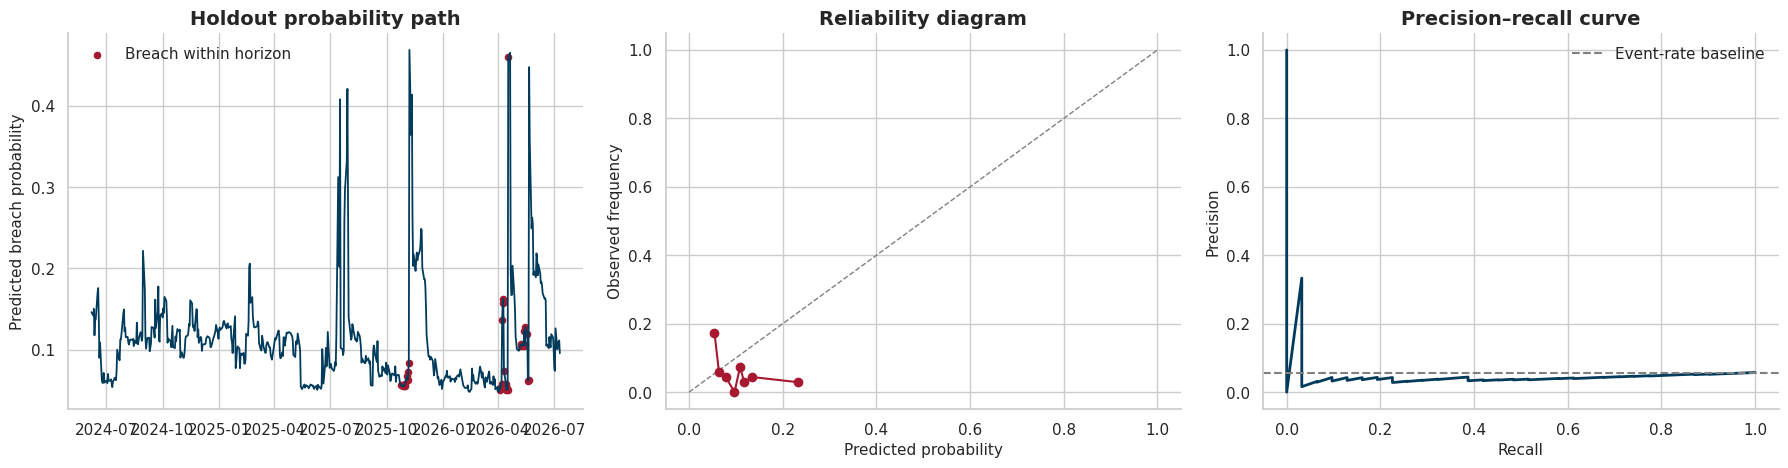

In [14]:
#@title 20. Locked-holdout diagnostics: time path, calibration, and precision–recall
holdout_diag = HOLDOUT[["y_breach"]].copy()
holdout_diag["p_breach"] = holdout_p

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].plot(holdout_diag.index, holdout_diag.p_breach, color=CAMBRIDGE_BLUE, lw=1.3)
event_dates = holdout_diag.index[holdout_diag.y_breach == 1]
axes[0].scatter(
    event_dates, holdout_diag.loc[event_dates, "p_breach"],
    color=CAMBRIDGE_RED, s=20, label="Breach within horizon"
)
axes[0].set_title("Holdout probability path")
axes[0].set_ylabel("Predicted breach probability")
axes[0].legend(frameon=False)

prob_true, prob_pred = calibration_curve(
    holdout_y, holdout_p,
    n_bins=min(8, max(3, int(np.sqrt(len(HOLDOUT))))),
    strategy="quantile"
)
axes[1].plot([0, 1], [0, 1], "--", color="gray", lw=1)
axes[1].plot(prob_pred, prob_true, "o-", color=CAMBRIDGE_RED)
axes[1].set_title("Reliability diagram")
axes[1].set_xlabel("Predicted probability")
axes[1].set_ylabel("Observed frequency")

precision, recall, _ = precision_recall_curve(holdout_y, holdout_p)
axes[2].plot(recall, precision, color=CAMBRIDGE_BLUE, lw=2)
axes[2].axhline(holdout_y.mean(), ls="--", color="gray", label="Event-rate baseline")
axes[2].set_title("Precision–recall curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

## 21. From event probability to FX loss severity

A probability of barrier breach is not yet a complete risk measure. The notebook also estimates the conditional distribution of the \(H\)-day log return using quantile gradient boosting. For a linear FX exposure, the lower return quantile is converted into an approximate 99% VaR.

For options, nonlinear hedges, or balance-sheet translation exposures, replace the linear P&L approximation with a full revaluation function.

In [15]:
#@title 22. Fit conditional return quantiles and estimate tail severity
BEST_QCFG = STATE.best_quantum_config
severity_train = frame_for_qcfg(DESIGN, BEST_QCFG)
severity_holdout = frame_for_qcfg(HOLDOUT, BEST_QCFG)
SEVERITY_COLS = CLASSICAL_COLS + Q_COLS

quantile_levels = [CFG.tail_alpha, 0.50, 1 - CFG.tail_alpha]
quantile_models = {}
quantile_predictions = {}

for q in quantile_levels:
    model = GradientBoostingRegressor(
        loss="quantile",
        alpha=q,
        n_estimators=180,
        learning_rate=0.04,
        max_depth=2,
        min_samples_leaf=20,
        random_state=SEED,
    )
    model.fit(severity_train[SEVERITY_COLS], DESIGN["fwd_return"])
    quantile_models[q] = model
    quantile_predictions[q] = model.predict(severity_holdout[SEVERITY_COLS])

coverage = np.mean(
    (HOLDOUT["fwd_return"].to_numpy() >= quantile_predictions[CFG.tail_alpha]) &
    (HOLDOUT["fwd_return"].to_numpy() <= quantile_predictions[1 - CFG.tail_alpha])
)
print(f"Empirical coverage of the nominal {100*(1-2*CFG.tail_alpha):.0f}% interval: {coverage:.2%}")

# Empirical breach-conditioned severity complements the conditional quantile model.
breach_returns = DESIGN.loc[DESIGN.y_breach == 1, "fwd_return"]
downside_es_return = float(
    breach_returns[breach_returns <= breach_returns.quantile(CFG.tail_alpha)].mean()
)
print({
    "breach_conditioned_downside_ES_log_return": round(downside_es_return, 5),
    "number_of_design_breach_labels": int(len(breach_returns)),
})

Empirical coverage of the nominal 98% interval: 95.24%
{'breach_conditioned_downside_ES_log_return': -0.07572, 'number_of_design_breach_labels': 177}


In [16]:
#@title 23. Current target-zone risk card
LATEST = dataset.iloc[[-1]].copy()
latest_p = float(predict_bundle(FINAL_BUNDLE, LATEST)[0])
latest_frame = frame_for_qcfg(LATEST, BEST_QCFG)

q_lo = float(quantile_models[CFG.tail_alpha].predict(latest_frame[SEVERITY_COLS])[0])
q_med = float(quantile_models[0.50].predict(latest_frame[SEVERITY_COLS])[0])
q_hi = float(quantile_models[1 - CFG.tail_alpha].predict(latest_frame[SEVERITY_COLS])[0])

# Linearized quoted-FX P&L. Adapt exposure_sign and revaluation for the real position.
pnl_q01 = CFG.fx_notional * CFG.exposure_sign * q_lo
var_99 = max(-pnl_q01, 0.0)
breach_es_amount = max(-CFG.fx_notional * CFG.exposure_sign * downside_es_return, 0.0)

risk_card = pd.DataFrame({
    "Measure": [
        "Deployment gate",
        f"Probability of any barrier breach in next {CFG.breach_horizon_days} business days",
        "Conditional 1% FX log-return quantile",
        "Conditional median FX log return",
        "Conditional 99% FX log-return quantile",
        "Approximate linear 99% VaR",
        "Empirical breach-conditioned downside ES",
        "Location inside band (-1 lower, +1 upper)",
        "Distance to nearest barrier (fraction of band)",
    ],
    "Value": [
        DEPLOYMENT_STATUS,
        f"{latest_p:.2%}",
        f"{q_lo:.3%}",
        f"{q_med:.3%}",
        f"{q_hi:.3%}",
        f"{var_99:,.0f}",
        f"{breach_es_amount:,.0f}",
        f"{float(LATEST.location.iloc[0]):.3f}",
        f"{float(LATEST.dist_nearest.iloc[0]):.3f}",
    ]
})
risk_card

,Measure,Value
0,Deployment gate,REJECTED — RESEARCH ONLY
1,Probability of any barrier breach in next 10 b...,9.55%
2,Conditional 1% FX log-return quantile,-2.724%
3,Conditional median FX log return,-0.408%
4,Conditional 99% FX log-return quantile,2.511%
5,Approximate linear 99% VaR,"272,370"
6,Empirical breach-conditioned downside ES,"757,222"
7,"Location inside band (-1 lower, +1 upper)",0.322
8,Distance to nearest barrier (fraction of band),0.339


In [ ]:
#@title 24. Governed stress scenarios
def apply_stress(one_row: pd.DataFrame, scenario: str):
    z = one_row.copy()
    if scenario in {"Volatility +50%", "Combined shock"}:
        for c in ["vol_5", "vol_20", "vol_60"]:
            z[c] *= 1.50
        z["vol_ratio"] *= 1.20
        z["barrier_pressure"] *= 1.25
    if scenario in {"Band narrows 20%", "Combined shock"}:
        z["dist_upper"] *= 0.80
        z["dist_lower"] *= 0.80
        z["dist_nearest"] *= 0.80
        z["band_width_pct"] *= 0.80
        z["barrier_pressure"] /= 0.80
    if scenario in {"Credibility shock", "Combined shock"}:
        z["defense_proxy"] -= 1.0
        z["barrier_pressure"] *= 1.50
    return z


scenario_names = [
    "Baseline", "Volatility +50%", "Band narrows 20%",
    "Credibility shock", "Combined shock"
]
scenario_rows = []
for scenario in scenario_names:
    stressed = LATEST if scenario == "Baseline" else apply_stress(LATEST, scenario)
    scenario_rows.append({
        "Scenario": scenario,
        "Breach probability": float(predict_bundle(FINAL_BUNDLE, stressed)[0]),
    })
SCENARIOS = pd.DataFrame(scenario_rows)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(
    SCENARIOS["Scenario"], SCENARIOS["Breach probability"],
    color=[CAMBRIDGE_BLUE] + [CAMBRIDGE_RED] * (len(SCENARIOS) - 1)
)
ax.set_ylabel("Predicted breach probability")
ax.set_title("Current risk under governed target-zone stresses")
ax.tick_params(axis="x", rotation=20)
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()
SCENARIOS.assign(
    **{"Breach probability": SCENARIOS["Breach probability"].map(lambda x: f"{x:.2%}")}
)

## 25. How to interpret the winner

Use the following decision rules:

- **Hybrid wins materially:** quantum-inspired nonlinearities add information that the selected ML model exploits. This supports continued research, not a claim of quantum market mechanics.
- **Blend wins:** different model families make partially independent errors; diversified probabilities improve the governed loss.
- **Classical model wins:** the tunneling features are unnecessary for this dataset or mapping. Retain the negative result.
- **Quantum-only wins:** investigate carefully. It may represent a genuinely compact barrier geometry, but it may also indicate that classical features or ML settings were poorly specified.
- **Holdout underperforms the benchmark:** do not deploy. Record the failure, revisit the economic design, obtain a new untouched evaluation period, and repeat as a new governed experiment.

For institutional use, add transaction-specific P&L revaluation, macroeconomic predictors, reserve/forward-market data, central-bank intervention data, policy announcements, regime-change labels, conformal uncertainty, drift monitoring, and independent model validation.

In [ ]:
#@title 26. Full audit bundle and experiment manifest
AUDIT_LOG = pd.DataFrame(STATE.audit)
MANIFEST = {
    "experiment": "Agentic Quantum–ML FX Target-Zone Risk",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "author": "Alejandro Reynoso",
    "seed": SEED,
    "data_fingerprint": DATA_FINGERPRINT,
    "configuration": asdict(CFG),
    "design_period": [str(DESIGN.index.min()), str(DESIGN.index.max())],
    "holdout_period": [str(HOLDOUT.index.min()), str(HOLDOUT.index.max())],
    "holdout_was_locked_during_selection": True,
    "agent_cycles": STATE.cycle,
    "candidates_evaluated": STATE.candidates_used,
    "best_quantum_config": asdict(STATE.best_quantum_config),
    "champion_spec": CHAMPION_SPEC,
    "holdout_metrics": HOLDOUT_METRICS,
    "benchmark_holdout_metrics": BENCHMARK_METRICS,
    "deployment_status": DEPLOYMENT_STATUS,
    "limitations": [
        "Quantum tunneling is a mathematical analogy, not a claim of quantum FX dynamics.",
        "Synthetic results do not establish live-market performance.",
        "A statistical rolling band is not an official target zone.",
        "Linear VaR is unsuitable for nonlinear portfolios without full revaluation.",
    ],
}

print(json.dumps(MANIFEST, indent=2, default=str))
AUDIT_LOG[["cycle", "phase", "event"]].tail(20)

In [ ]:
#@title 27. Optional: export the audit artifacts from Colab
from pathlib import Path

export_dir = Path("/content/fx_target_zone_audit")
export_dir.mkdir(parents=True, exist_ok=True)
LEADERBOARD.to_csv(export_dir / "leaderboard.csv", index=False)
holdout_report.to_csv(export_dir / "holdout_report.csv", index=False)
SCENARIOS.to_csv(export_dir / "stress_scenarios.csv", index=False)
AUDIT_LOG.to_json(export_dir / "agent_audit_log.json", orient="records", indent=2)
(export_dir / "experiment_manifest.json").write_text(
    json.dumps(MANIFEST, indent=2, default=str), encoding="utf-8"
)
print(f"Audit bundle written to: {export_dir}")

## 28. References and primary sources

1. Krugman, P. R. (1988). **Target Zones and Exchange Rate Dynamics.** NBER Working Paper 2481.  
   https://www.nber.org/papers/w2481

2. Flood, R. P., & Garber, P. M. (1989). **The Linkage Between Speculative Attack and Target Zone Models of Exchange Rates.** NBER Working Paper 2918.  
   https://www.nber.org/papers/w2918

3. Svensson, L. E. O. (1992). **An Interpretation of Recent Research on Exchange Rate Target Zones.** *Journal of Economic Perspectives*, 6(4), 119–144.  
   https://www.aeaweb.org/articles?id=10.1257/jep.6.4.119

4. Bekaert, G., & Gray, S. F. (1998). **Target Zones and Exchange Rates: An Empirical Investigation.** *Journal of International Economics*, 45(1), 1–35.  
   https://business.columbia.edu/sites/default/files-efs/imce-uploads/gbekaert/papers/target%20zones.pdf

5. Racorean, O. S. (2014). **Quantum Tunneling of Stock Price in Range Bound Market.** *Applied Mathematics & Information Sciences*, 8(1), 15–23.  
   https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2519103

6. Filippou, I., Rapach, D. E., Taylor, M. P., & Zhou, G. (2021). **Exchange Rate Prediction with Machine Learning and a Smart Carry Trade Portfolio.**  
   https://www.wu.ac.at/fileadmin/wu/d/ri/isk/VSFX_2021/Papers/Rapach_SmartCarry_07-02-2021.pdf

7. Scikit-learn developers. **TimeSeriesSplit.**  
   https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html

8. Scikit-learn developers. **Probability calibration and Brier score.**  
   https://scikit-learn.org/stable/modules/calibration.html

---

### Final methodological principle

> The loop is not asked to prove that tunneling is true. It is asked to determine whether a transparent tunneling representation improves governed, out-of-sample FX risk estimation when barriers matter.